In [1]:
%load_ext autoreload
%autoreload 2

Quickly setup enough code to have some theory and data

In [2]:
from functools import partial

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxpower import BinMesh2SpectrumPoles, FKPField, ParticleField, compute_fkp2_normalization, get_mesh_attrs, compute_normalization
from jaxpower.mesh import _get_extent
from lsstypes import cov, mean, read
from tqdm import tqdm

from desiforwardwindow.convenience import fiducial_planck_2018, get_randoms
from desiforwardwindow.forward import get_AIC_foward_model, get_RIC_forward_model, mock_survey, mock_survey_mesh
from desiforwardwindow.window import get_window_geometry, get_window_spikes


In [3]:
LOS = "local"
UNITARY_AMPLITUDE = True
BATCH_SIZE = 1

n_bins_RIC = 1000 # distance bins for the shells in RIC

In [4]:
tracer = "LRG"
positions, stored_weights = get_randoms(n_randoms=5, region="SGC", zrange=(0.4, 1.1), tracer=tracer, weight_type="default")
boxsize = jnp.array([8000.0, 8000.0, 8000.0])
cellsize = 50.
#data_size = 1677566 # amount of data in the corresponding data catalog
data_size = positions.shape[0] // 3

stored_weights = stored_weights[0]

In [5]:
seed = jax.random.key(42)
data_indices_in_randoms = jax.random.choice(key=seed, a=stored_weights.size, shape=[data_size], replace=False).astype(int)
mask_is_data = jnp.zeros_like(stored_weights, dtype=bool).at[data_indices_in_randoms].set(True)
mask_is_randoms = jnp.invert(mask_is_data)

In [6]:
pos_min, pos_max = _get_extent(positions)
boxcenter = 0.5 * (pos_min + pos_max)
get_RIC_weights = get_RIC_forward_model(data_positions=positions[mask_is_data], randoms_positions=positions[mask_is_randoms], randoms_weights=stored_weights[mask_is_randoms], boxcenter=boxcenter, boxsize=boxsize, n_bins_RIC=n_bins_RIC)

In [7]:
mattrs = get_mesh_attrs(positions, cellsize=cellsize, boxsize=boxsize, check=True)  # [8000.0, 16000.0, 8000.0], check=True)
# Can pre-paint the randoms, since they won't move. Can't paint data.
randoms = ParticleField(positions[mask_is_randoms], weights=stored_weights[mask_is_randoms], attrs=mattrs, exchange=True)
randoms_mesh = randoms.paint(resampler="tsc", interlacing=3, compensate=True)
randoms_shotnoise = (randoms.weights**2).sum()
data = ParticleField(positions[mask_is_data], weights=stored_weights[mask_is_data], attrs=mattrs, exchange=True)

del positions, stored_weights

In [8]:
alpha = data.sum() / randoms.sum()
selection = alpha * randoms_mesh

In [9]:
# To go from the mesh to the observed power spectrum
# Can always rebin ell = 2 to 0.002 later
binner = BinMesh2SpectrumPoles(randoms.attrs, edges={"step": 0.001}, ells=(0, 2, 4))

# Precompute norms with fixed cellsize (10) and CIC resampling 
# (unlike meshes for P(k) estimation which are TSC, compensented and interlacing=3)
# Precompute the FKP power spectrum norm, without accounting for future data painting
FKP_field = FKPField(data=data, randoms=randoms)
fkp_norm = compute_fkp2_normalization(FKP_field, bin=binner, cellsize=10) # This uses CIC by default
del FKP_field

selection_norm = compute_normalization(alpha * randoms, alpha * randoms, bin=binner, cellsize=10)

In [10]:
theory = fiducial_planck_2018(jnp.arange(0.0, mattrs.knyq.max(), 0.001)) # Stop at the selection's k_nyq

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/code/cosmoprimo/main/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


In [11]:
nreal_fw = 40

In [12]:
forward_model_cat = jax.jit(
    partial(
        mock_survey,
        theory=theory,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        binner=binner,
        randoms_shotnoise=randoms_shotnoise,
        fkp_norm=fkp_norm,
        get_AIC_weights=None,
    ),
    static_argnames=["get_RIC_weights"],
)
# left: seed, data, randoms_mesh, get_AIC_weights, get_RIC_weights

In [13]:
cat_geo = [forward_model_cat(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=None) for seed in tqdm(range(nreal_fw))]
#cat_RIC = [forward_model_cat(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=get_RIC_weights) for seed in tqdm(range(nreal_fw))]

100%|██████████| 40/40 [00:09<00:00,  4.37it/s]


In [14]:
forward_model_mesh = jax.jit(
    partial(
        mock_survey_mesh,
        theory=theory,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        binner=binner,
        norm=fkp_norm #[s/alpha**2 for s in selection_norm],
    ),
    static_argnames=["ric"],
)
# left: seed, selection, get_RIC_weights

In [15]:
mesh_geo = [forward_model_mesh(seed=jax.random.key(seed), selection=selection, ric=False) for seed in tqdm(range(nreal_fw))]
#mesh_RIC = [forward_model_mesh(seed=jax.random.key(seed), selection=randoms_mesh, ric=True) for seed in tqdm(range(nreal_fw))]

100%|██████████| 40/40 [00:05<00:00,  7.66it/s]


In [16]:
cat_geo_mean = mean(cat_geo)
cat_geo_cov = cov(cat_geo)
mesh_geo_mean = mean(mesh_geo)
mesh_geo_cov = cov(mesh_geo)

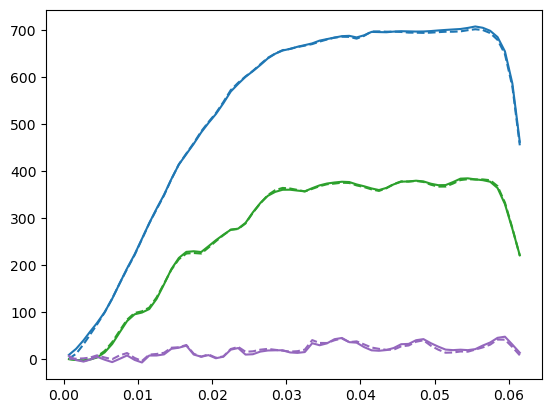

In [17]:
for ell in [0, 2, 4]:
    color=f"C{ell}"
    polecat = cat_geo_mean.get(ell)
    stdcat = cat_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(40)
    polemesh = mesh_geo_mean.get(ell)
    stdmesh = mesh_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(40)

    plt.plot(polecat.coords('k'), polecat.coords('k') * polecat.value(), label="Catalog", color=color, ls='--')
    plt.plot(polemesh.coords('k'), polemesh.coords('k') * polemesh.value(), label="Mesh", color=color, ls='-')

    

Text(0.5, 0.01, '$k$')

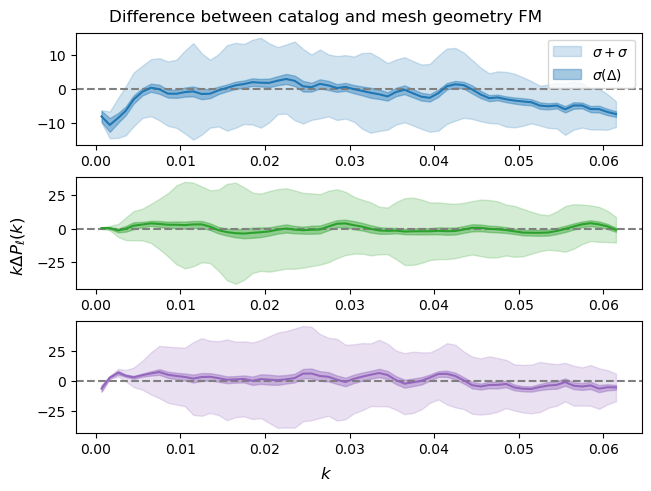

In [18]:
fig, lax = plt.subplots(3, 1, layout="constrained")

for ell in [0, 2, 4]:
    color=f"C{ell}"
    polecat = cat_geo_mean.get(ell)
    stdcat = cat_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(nreal_fw)
    polemesh = mesh_geo_mean.get(ell)
    stdmesh = mesh_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(nreal_fw)

    stddiff = cov([pkcat.clone(value=pkcat.value() - pkmesh.value()) for pkcat, pkmesh in zip(cat_geo, mesh_geo)]).at.observable.get(ell).std().real / jnp.sqrt(nreal_fw)
    lax[ell//2].axhline(0, color="gray", ls='--')
    lax[ell//2].plot(polecat.coords('k'),
                     polecat.coords('k') * (polecat.value() - polemesh.value()), label=None, color=color, ls='-')
    lax[ell//2].fill_between(polecat.coords('k'), 
                             polecat.coords('k') * (polecat.value() - polemesh.value() - stdcat - stdmesh),
                             polecat.coords('k') * (polecat.value() - polemesh.value() + stdcat + stdmesh),
                             color=color, alpha=0.2, label="$\sigma + \sigma$",
                            )
    lax[ell//2].fill_between(polecat.coords('k'), 
                             polecat.coords('k') * (polecat.value() - polemesh.value() - stddiff),
                             polecat.coords('k') * (polecat.value() - polemesh.value() + stddiff),
                             color=color, alpha=0.4, label="$\sigma(\Delta)$",
                            )
lax[0].legend()
fig.suptitle("Difference between catalog and mesh geometry FM")
fig.supylabel(r"$k \Delta P_\ell(k)$")
fig.supxlabel("$k$")

/tmp/ipykernel_147046/3302612781.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  lax[0].legend()


Text(0.5, 0.01, '$k$')

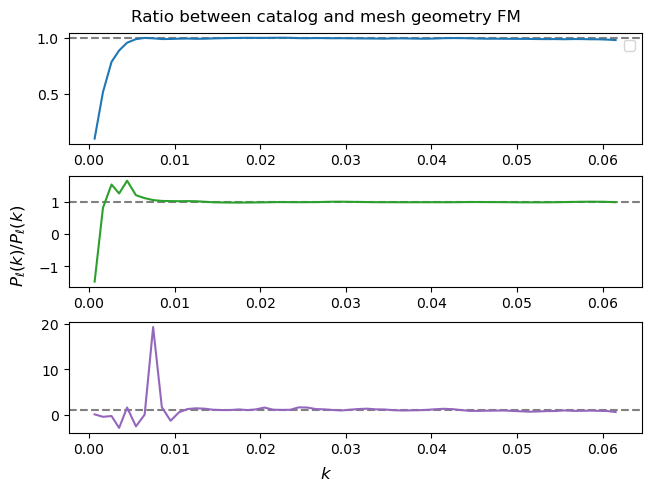

In [19]:
fig, lax = plt.subplots(3, 1, layout="constrained")

for ell in [0, 2, 4]:
    color=f"C{ell}"
    polecat = cat_geo_mean.get(ell)
    stdcat = cat_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(nreal_fw)
    polemesh = mesh_geo_mean.get(ell)
    stdmesh = mesh_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(nreal_fw)

    stddiff = cov([pkcat.clone(value=pkcat.value() - pkmesh.value()) for pkcat, pkmesh in zip(cat_geo, mesh_geo)]).at.observable.get(ell).std().real / jnp.sqrt(nreal_fw)
    lax[ell//2].axhline(1, color="gray", ls='--')
    lax[ell//2].plot(polecat.coords('k'),
                     (polecat.value() / polemesh.value()), label=None, color=color, ls='-')
#    lax[ell//2].fill_between(polecat.coords('k'), 
#                             (polecat.value() - polemesh.value() - stdcat - stdmesh),
#                             (polecat.value() - polemesh.value() + stdcat + stdmesh),
#                             color=color, alpha=0.2, label="$\sigma + \sigma$",
#                            )
#    lax[ell//2].fill_between(polecat.coords('k'), 
#                             (polecat.value() - polemesh.value() - stddiff),
#                             (polecat.value() - polemesh.value() + stddiff),
#                             color=color, alpha=0.4, label="$\sigma(\Delta)$",
#                            )
#    lax[ell//2].set_ylim(0.95, 1.1)
    
lax[0].legend()
fig.suptitle("Ratio between catalog and mesh geometry FM")
fig.supylabel(r"$P_\ell(k) / P_\ell(k)$")
fig.supxlabel("$k$")

# Do the same checks without a selection

Take data and randoms with a completely uniform distribution in the box.

In [20]:
urandoms_positions = jax.random.uniform(key=jax.random.key(42),
                               shape=(randoms.positions.shape[0]*5, 3),
                               minval=(boxcenter - boxsize/2),
                               maxval = (boxcenter + boxsize/2),
                              )

udata_positions = jax.random.uniform(key=jax.random.key(43),
                               shape=(data.positions.shape[0]*5, 3),
                               minval=(boxcenter - boxsize/2),
                               maxval = (boxcenter + boxsize/2),
                                    )

In [21]:
urandoms_shotnoise = urandoms_positions.shape[0] # sum of squdata.positions.shapeared weights but weights are 1

In [22]:
urandoms = ParticleField(urandoms_positions, weights=1.0, attrs=mattrs, exchange=True)
udata = ParticleField(udata_positions, weights=1.0, attrs=mattrs, exchange=True)

In [23]:
uFKP_field = FKPField(data=udata, randoms=urandoms)
ufkp_norm = compute_fkp2_normalization(uFKP_field, bin=binner)

In [24]:
urandoms_mesh = urandoms.paint(resampler='tsc', compensate=True, interlacing=3)

In [32]:
from jaxpower import generate_anisotropic_gaussian_mesh, compute_mesh2_spectrum, compute_normalization, compute_box2_normalization

@jax.jit
def uforward_model_cat(data, seed):
    mattrs = data.attrs
    mesh = generate_anisotropic_gaussian_mesh(
        mattrs,
        poles=theory,
        seed=seed,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
    )
    # Paint it on the portion of randoms designated as "data" -> data catalog w/ geometry
    data_field = data.clone(weights=data.weights * (mesh.read(data.positions, resampler="cic", compensate=True, exchange=True) + 1))
    del mesh
    # Paint to mesh for P(k) computation and build FKP mesh
    data_mesh = data_field.paint(resampler="tsc", interlacing=3, compensate=True, out="real")
    shot_noise = (data_field.weights**2).sum()
    norm = compute_box2_normalization(data_field, data_field, bin=binner)
    pk = compute_mesh2_spectrum(data_mesh, data_mesh, bin=binner, los="firstpoint")
    return pk.clone(norm=norm, num_shotnoise=[shot_noise * (ell == 0) * jnp.ones_like(binner.edges[..., 0]) for ell in binner.ells])

@jax.jit
def uforward_model_mesh(mattrs, seed):
    mesh = generate_anisotropic_gaussian_mesh(
        mattrs,
        poles=theory,
        seed=seed,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
    )
    # Paint it on the portion of randoms designated as "data" -> data catalog w/ geometry
    pk = compute_mesh2_spectrum(mesh, bin=binner, los="firstpoint")
    return pk

# left: seed, data, randoms_mesh, get_AIC_weights, get_RIC_weights

In [26]:
unreal_fw = 100

In [27]:
ucat_geo = [uforward_model_cat(seed=jax.random.key(seed), data=udata) for seed in tqdm(range(unreal_fw))]

100%|██████████| 100/100 [01:12<00:00,  1.37it/s]


In [33]:
umesh_geo = [uforward_model_mesh(seed=jax.random.key(seed), mattrs=udata.attrs) for seed in tqdm(range(unreal_fw))]

100%|██████████| 100/100 [00:07<00:00, 12.77it/s]


In [34]:
ucat_geo_mean = mean(ucat_geo)
ucat_geo_cov = cov(ucat_geo)
umesh_geo_mean = mean(umesh_geo)
umesh_geo_cov = cov(umesh_geo)

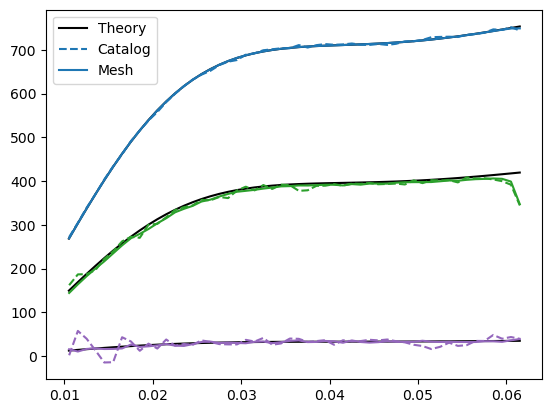

In [35]:
for ell in [0, 2, 4]:
    color=f"C{ell}"
    pole = theory.select(k=(0.01, 0.08)).get(ell)
    plt.plot(pole.coords('k'), pole.coords('k') * pole.value(), label="Theory", color='k', ls='-')
    polecat = ucat_geo_mean.select(k=(0.01, 0.08)).get(ell)
    #stdcat = ucat_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(40)
    polemesh = umesh_geo_mean.select(k=(0.01, 0.08)).get(ell)
    #stdmesh = umesh_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(40)

    plt.plot(polecat.coords('k'), polecat.coords('k') * polecat.value(), label="Catalog", color=color, ls='--')
    plt.plot(polemesh.coords('k'), polemesh.coords('k') * polemesh.value(), label="Mesh", color=color, ls='-')
    if ell == 0:
        plt.legend()
    

(0.75, 1.05)

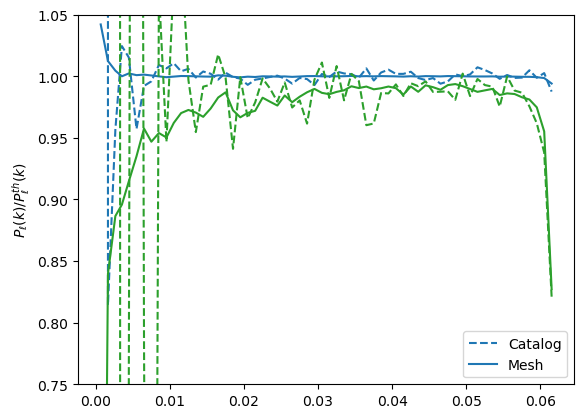

In [36]:
for ell in [0, 2]:
    color=f"C{ell}"
    pole = theory.select(k=(0.0, 0.08, 5)).get(ell)
    #plt.plot(pole.coords('k'), pole.coords('k') * pole.value(), label="Theory", color='k', ls='-')
    polecat = ucat_geo_mean.select(k=(0.0, 0.08, 5)).get(ell)
    #stdcat = ucat_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(40)
    polemesh = umesh_geo_mean.select(k=(0.0, 0.08, 5)).get(ell)
    #stdmesh = umesh_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(40)

    plt.plot(polecat.coords('k'), polecat.value() / pole.value(), label="Catalog", color=color, ls='--')
    plt.plot(polemesh.coords('k'), polemesh.value() / pole.value(), label="Mesh", color=color, ls='-')
    if ell == 0:
        plt.legend()
plt.ylabel("$P_\ell(k)/P_\ell^{th}(k)$")
plt.ylim(0.75, 1.05)
    